# MLP - Multi Layer Perceptron

In this notebook, we will implement a simple MLP to classify the MNIST dataset. The MNIST dataset consists of 28x28 pixel images of handwritten digits (0-9) and is commonly used for training various image processing systems.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# import keras
import tensorflow.keras as keras
import keras.layers as layers
import keras.optimizers as optimizers
import keras.models as models

In [3]:
LEARNING_RATE = 0.001
BATCH_SIZE = 128
N_EPOCHS = 20

In [4]:
# Load and prepare the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = x_train.astype('float32') / 255.0
X_test = x_test.astype('float32') / 255.0

In [5]:
# Create a simple dense MLP model using Sequential API
model_dense = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [6]:
model_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the model
model_dense.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

In [8]:
# Early stopping callback to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [9]:
# Train the model
history = model_dense.fit(X_train, y_train,
                          epochs=N_EPOCHS,
                          batch_size=BATCH_SIZE,
                          validation_data=(X_test, y_test),
                          callbacks=[early_stopping]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9007 - loss: 0.3623 - val_accuracy: 0.9434 - val_loss: 0.2003
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9513 - loss: 0.1706 - val_accuracy: 0.9582 - val_loss: 0.1419
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9658 - loss: 0.1227 - val_accuracy: 0.9665 - val_loss: 0.1161
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9725 - loss: 0.0966 - val_accuracy: 0.9724 - val_loss: 0.0946
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9775 - loss: 0.0780 - val_accuracy: 0.9743 - val_loss: 0.0895
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9807 - loss: 0.0651 - val_accuracy: 0.9763 - val_loss: 0.0817
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9843 - loss: 0.0538 - val_accuracy: 0.9771 - val_loss: 0.0770
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9870 - loss: 0.0458 - val_accuracy: 0.

In [10]:
# Evaluate the model on the test set
loss, acc = model_dense.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy:{acc:.4f}')

Test accuracy:0.9797


In [11]:
# create a concat dataset of all the X_train and X_test
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

In [12]:
# Do a global Evaluation of the model on the entire dataset
loss, acc = model_dense.evaluate(X, y, verbose=0)
print(f'Global accuracy:{acc:.4f}')

Global accuracy:0.9954


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 1s 417us/step


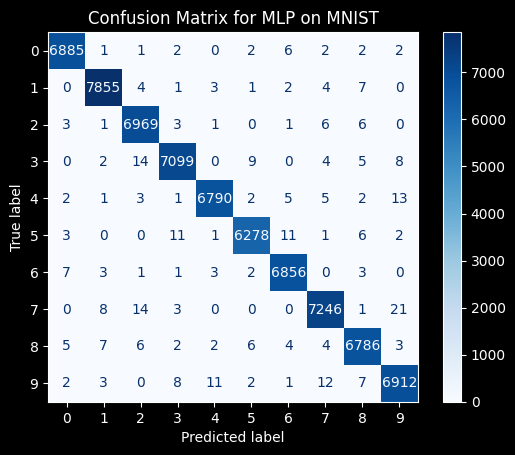

In [14]:
# Do a confusion matrix to see the performance of the model on each class
pred = model_dense.predict(X)
pred_classes = np.argmax(pred, axis=1)
cm = confusion_matrix(y, pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MLP on MNIST')
plt.show()

In [15]:
from sklearn.metrics import classification_report

# Print a classification report to see the precision, recall and f1-score for each class
report = classification_report(y, pred_classes, target_names=[str(i) for i in range(10)])
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6903
           1       1.00      1.00      1.00      7877
           2       0.99      1.00      1.00      6990
           3       1.00      0.99      0.99      7141
           4       1.00      1.00      1.00      6824
           5       1.00      0.99      1.00      6313
           6       1.00      1.00      1.00      6876
           7       0.99      0.99      0.99      7293
           8       0.99      0.99      0.99      6825
           9       0.99      0.99      0.99      6958

    accuracy                           1.00     70000
   macro avg       1.00      1.00      1.00     70000
weighted avg       1.00      1.00      1.00     70000



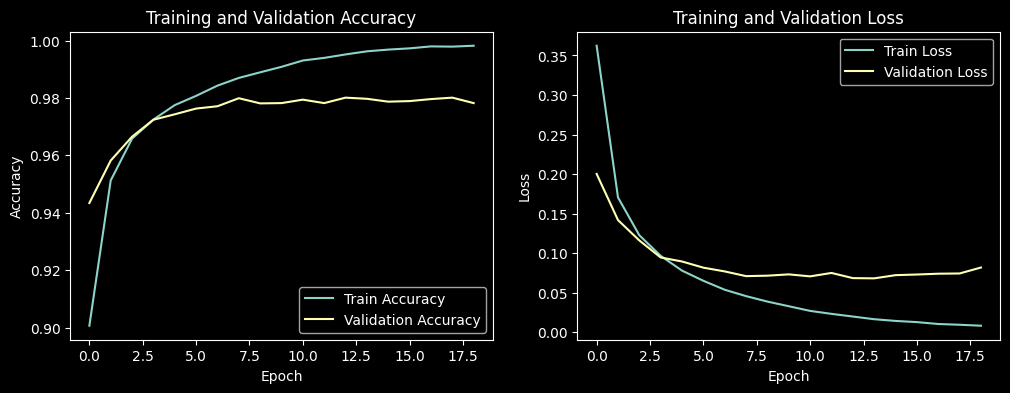

In [16]:
# Plot the training and validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

Compare the simple MLP to a SVM, or simple Logistic Regression model on the same dataset to see the difference in performance. You can use scikit-learn for this purpose.

In [17]:
from sklearn.svm import SVC

# Flatten the images for SVM
X_train_flat = X_train.reshape(X_train.shape[0], -1)[:500]
y_train_flat = y_train[:500]

# take only 500 example since it will take too much time to trina
X_test_flat = X_test.reshape(X_test.shape[0], -1)[:100]
y_test = y_test[:100]

# Train a simple SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_flat, y_train_flat)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
# Evaluate the SVM model
svm_pred = svm_model.predict(X_test_flat)

In [19]:
from sklearn.metrics import accuracy_score
svm_acc = accuracy_score(y_test, svm_pred)
print(f'SVM Test Accuracy: {svm_acc:.4f}')

SVM Test Accuracy: 0.9000


# Explore different activation functions

In [20]:
# reload the dataset to get the full test set
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize the pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [21]:
model_2 = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

In [22]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# compile the model
model_2.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

In [24]:
# fit the model
history_2 = model_2.fit(x_train, y_train,
                          epochs=50,
                          batch_size=BATCH_SIZE,
                          validation_data=(x_test, y_test),
                          callbacks=[early_stopping]
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8957 - loss: 0.3749 - val_accuracy: 0.9338 - val_loss: 0.2327
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9430 - loss: 0.1996 - val_accuracy: 0.9515 - val_loss: 0.1666
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9585 - loss: 0.1460 - val_accuracy: 0.9591 - val_loss: 0.1377
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9674 - loss: 0.1144 - val_accuracy: 0.9659 - val_loss: 0.1140
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9736 - loss: 0.0928 - val_accuracy: 0.9680 - val_loss: 0.1036


In [25]:
# validate the model on the test set
loss, acc = model_2.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy:{acc:.4f}')

Test accuracy:0.9338


In [26]:
# validate the model on the whole dataset
X = np.concatenate((x_train, x_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)
loss, acc = model_2.evaluate(X, y, verbose=0)
print(f'Global accuracy:{acc:.4f}')

Global accuracy:0.9347


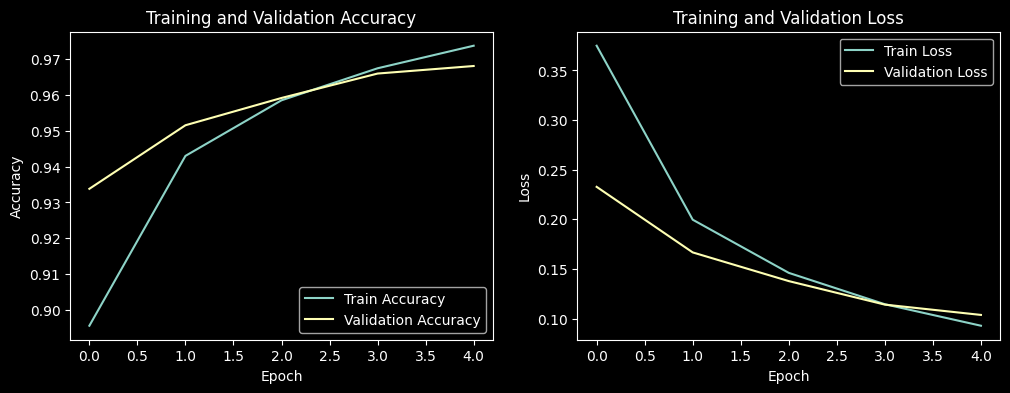

In [27]:
# plot the loss vs val_loss and acc vs val_acc
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

Just by using a different activation function, going from `relu` to `tanh`, we can see a significant difference in performance (92% vs 97% (99% one the whole dataset)). This is a good example of how important it is to experiment with different architectures and hyperparameters when training a neural network.

# Sigmoid ($\sigma(a)$) activation function

In [28]:
model_3 = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

In [29]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_3.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
# callbacks
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
learning_rate_monitor = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.05, patience=3, min_lr=1e-6)

In [32]:
# fit the model
history_3 = model_3.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    batch_size=BATCH_SIZE,
    epochs=50,
    callbacks=[early_stopping, learning_rate_monitor]
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8596 - loss: 0.6009 - val_accuracy: 0.9180 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9238 - loss: 0.2727 - val_accuracy: 0.9326 - val_loss: 0.2379 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9394 - loss: 0.2160 - val_accuracy: 0.9437 - val_loss: 0.1961 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9493 - loss: 0.1808 - val_accuracy: 0.9503 - val_loss: 0.1696 - learning_rate: 0.0010
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9558 - loss: 0.1558 - val_accuracy: 0.9570 - val_loss: 0.1500 - learning_rate: 0.0010
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9609 - loss: 0.1356 - val_accuracy: 0.9597 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9661 - loss: 0.1200 - 

In [33]:
# test the model
loss, acc = model_3.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy:{acc:.4f}')

Test accuracy:0.9787


Make a deeper model with dropout regularization to see if we can improve the performance even more

In [34]:
model_4 = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [35]:
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model_4.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
model_4.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    batch_size=BATCH_SIZE,
    epochs=50,
    callbacks=[early_stopping, learning_rate_monitor]
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8390 - loss: 0.5228 - val_accuracy: 0.9455 - val_loss: 0.1743 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9291 - loss: 0.2469 - val_accuracy: 0.9614 - val_loss: 0.1259 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9439 - loss: 0.1941 - val_accuracy: 0.9671 - val_loss: 0.1083 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9557 - loss: 0.1541 - val_accuracy: 0.9708 - val_loss: 0.1017 - learning_rate: 5.0000e-05
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9583 - loss: 0.1438 - val_accuracy: 0.9702 - val_loss: 0.0977 - learning_rate: 5.0000e-05


In [38]:
# test the model
loss, acc = model_4.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy:{acc:.4f}')

Test accuracy:0.9702


In [41]:
# test all the models on the whole dataset
X = np.concatenate((x_train, x_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)
for i, model in enumerate([model_dense, model_2, model_3, model_4]):
    loss, acc = model.evaluate(X, y, verbose=0)
    print(f'Model {i+1} Global accuracy: {100 * acc:.4f}%')

Model 1 Global accuracy: 99.5371%
Model 2 Global accuracy: 93.4714%
Model 3 Global accuracy: 99.6271%
Model 4 Global accuracy: 97.5686%
